KNN Regression

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## DataCleansing

In [5]:
df=pd.read_csv('preprocessed_data.csv')


In [12]:
df.head()

,age,placement_status,gpa,boolean_Computer Science,boolean_Information Technology,boolean_Electrical Engineering,boolean_Mechanical Engineering,boolean_Electronics and Communication
0,25,1,3.7,1,0,0,0,0
1,24,1,3.6,0,0,1,0,0
2,26,1,3.8,0,0,0,1,0
3,23,0,3.5,0,1,0,0,0
4,24,1,3.9,1,0,0,0,0


In [ ]:
# from sklearn.preprocessing import LabelEncoder

# # One-hot encode the stream column and convert to 0/1
# boolean_encoded = pd.get_dummies(
#     input_df["stream"], 
#     prefix="boolean",
#     dtype=int
# )

# # Convert placement_status to 0/1
# le = LabelEncoder()
# input_df["placement_status"] = le.fit_transform(input_df["placement_status"])

# # Combine with original dataframe
# input_df_encoded = pd.concat([input_df, boolean_encoded], axis=1)

# # Select required columns
# new_df = input_df_encoded[
#     [
#         "age",
#         "placement_status",
#         "gpa",
#         "boolean_Computer Science",
#         "boolean_Information Technology",
#         "boolean_Electrical Engineering",
#         "boolean_Mechanical Engineering",
#         "boolean_Electronics and Communication"
#     ]
# ]

# new_df.head()

,age,placement_status,gpa,boolean_Computer Science,boolean_Information Technology,boolean_Electrical Engineering,boolean_Mechanical Engineering,boolean_Electronics and Communication
0,25,1,3.7,1,0,0,0,0
1,24,1,3.6,0,0,1,0,0
2,26,1,3.8,0,0,0,1,0
3,23,0,3.5,0,1,0,0,0
4,24,1,3.9,1,0,0,0,0


In [ ]:
# new_df.to_csv("preprocessed_data.csv", index=False)

In [ ]:
# df = new_df

## KNN Model

### train & inference (Unweighted Distance)

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler




Best k: 5


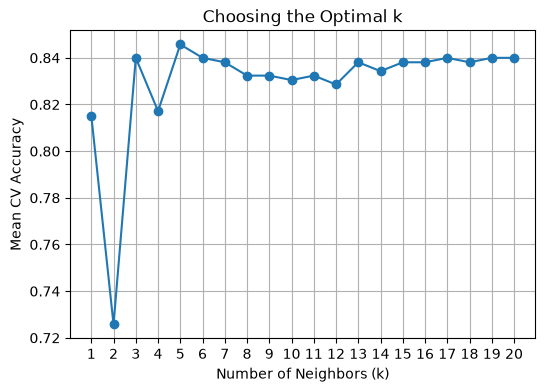

In [22]:


# Select features and target
features = [
    "age",
    "gpa",
    "boolean_Computer Science",
    "boolean_Information Technology",
    "boolean_Electrical Engineering",
    "boolean_Mechanical Engineering",
    "boolean_Electronics and Communication"
]

X = df[features]
y = df["placement_status"]



# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)



# Scale features (important for KNN)
# because higher age doesn't mean higher distance neccessarily. 
# this is just to make sure both age and gpa is on same range of 0 to 1. 

# scaler = MinMaxScaler()
# X = scaler.fit_transform(X)

# Scale features using Z-score Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



# optimal K 
# Find the best k using the training set
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    cv_scores.append(scores.mean())

best_k = k_values[cv_scores.index(max(cv_scores))]

print("Best k:", best_k)

# Plot CV accuracy
plt.figure(figsize=(6,4))
plt.plot(k_values, cv_scores, marker="o")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean CV Accuracy")
plt.title("Choosing the Optimal k")
plt.xticks(k_values)
plt.grid(True)
plt.show()





# Create KNN model
knn = KNeighborsClassifier(n_neighbors=best_k)


# Train the model
knn.fit(X_train, y_train)


# Make predictions
y_pred = knn.predict(X_test)




### Train / Inference (Weighted Distance)

Best k (Weighted): 18


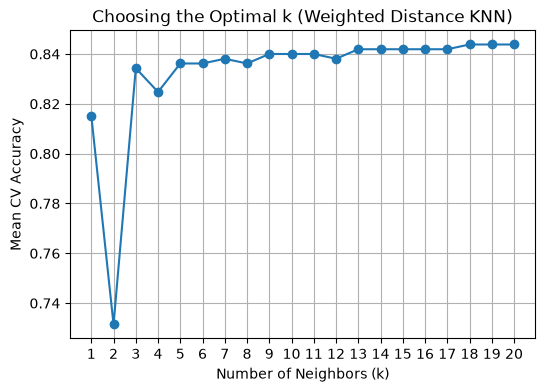

In [23]:
# Select features and target
features = [
    "age",
    "gpa",
    "boolean_Computer Science",
    "boolean_Information Technology",
    "boolean_Electrical Engineering",
    "boolean_Mechanical Engineering",
    "boolean_Electronics and Communication"
]

X = df[features]
y = df["placement_status"]


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)


# Scale features using Z-score Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ============================
# Find the optimal k (Weighted Distance KNN)
# ============================

k_values = range(1, 21)
cv_scores_weighted = []

for k in k_values:
    knn_weighted = KNeighborsClassifier(
        n_neighbors=k,
        weights="distance"
    )

    scores = cross_val_score(
        knn_weighted,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_scores_weighted.append(scores.mean())

best_k_weighted = k_values[
    cv_scores_weighted.index(max(cv_scores_weighted))
]

print("Best k (Weighted):", best_k_weighted)

# Plot CV accuracy
plt.figure(figsize=(6,4))
plt.plot(k_values, cv_scores_weighted, marker="o")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean CV Accuracy")
plt.title("Choosing the Optimal k (Weighted Distance KNN)")
plt.xticks(k_values)
plt.grid(True)
plt.show()


# ============================
# Create Weighted Distance KNN model
# ============================

knn_weighted = KNeighborsClassifier(
    n_neighbors=best_k_weighted,
    weights="distance"
)

# Train the model
knn_weighted.fit(X_train, y_train)

# Make predictions
y_pred_weighted = knn_weighted.predict(X_test)

# Predict probabilities (for ROC-AUC)
y_prob_weighted = knn_weighted.predict_proba(X_test)[:, 1]

### Evaluate

In [19]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

### Unweighted Model Evlauation

Accuracy: 74.86 %
Error Rate: 25.14 %

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.11      0.19        46
           1       0.75      0.98      0.85       129

    accuracy                           0.75       175
   macro avg       0.69      0.54      0.52       175
weighted avg       0.72      0.75      0.68       175



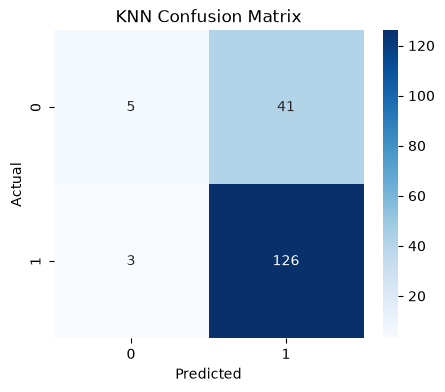

ROC-AUC Score: 0.711


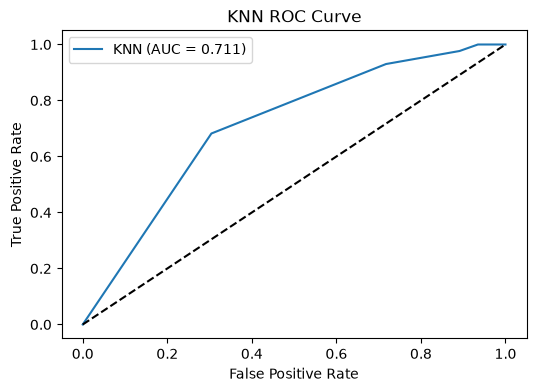

In [20]:
# Import additional evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


# ============================
# Model Evaluation
# ============================

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")


# Error Rate
error_rate = 1 - accuracy

print("Error Rate:", round(error_rate * 100, 2), "%")


# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ROC-AUC
# Need probability predictions instead of class predictions
y_prob = knn.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 3))


# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))

plt.plot(
    fpr,
    tpr,
    label=f"KNN (AUC = {roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.show()

### Weighted Model Evaluation

Weighted KNN Accuracy: 75.43 %
Weighted KNN Error Rate: 24.57 %

Weighted KNN Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.20      0.30        46
           1       0.77      0.95      0.85       129

    accuracy                           0.75       175
   macro avg       0.68      0.57      0.57       175
weighted avg       0.72      0.75      0.71       175



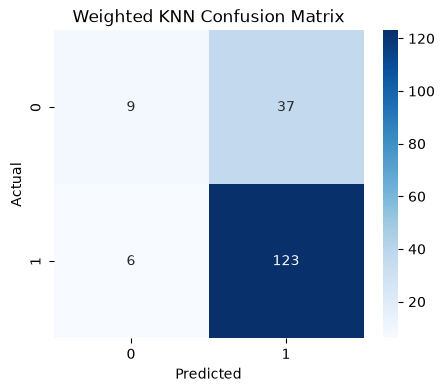

Weighted KNN ROC-AUC Score: 0.723


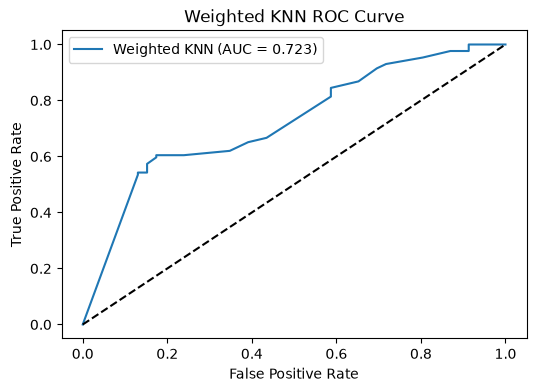

In [24]:
# ============================
# Weighted KNN Model Evaluation
# ============================

# Accuracy
accuracy_weighted = accuracy_score(y_test, y_pred_weighted)

print("Weighted KNN Accuracy:", round(accuracy_weighted * 100, 2), "%")


# Error Rate
error_rate_weighted = 1 - accuracy_weighted

print("Weighted KNN Error Rate:", round(error_rate_weighted * 100, 2), "%")


# Classification Report
print("\nWeighted KNN Classification Report:")
print(classification_report(y_test, y_pred_weighted))


# Confusion Matrix
cm_weighted = confusion_matrix(y_test, y_pred_weighted)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_weighted,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Weighted KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ROC-AUC
roc_auc_weighted = roc_auc_score(y_test, y_prob_weighted)

print("Weighted KNN ROC-AUC Score:", round(roc_auc_weighted, 3))


# ROC Curve
fpr_weighted, tpr_weighted, thresholds_weighted = roc_curve(
    y_test,
    y_prob_weighted
)

plt.figure(figsize=(6, 4))

plt.plot(
    fpr_weighted,
    tpr_weighted,
    label=f"Weighted KNN (AUC = {roc_auc_weighted:.3f})"
)

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Weighted KNN ROC Curve")
plt.legend()
plt.show()